In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# 1. โหลดข้อมูล
df_race = pd.read_csv('f1_enhanced_dataset_for_analysis.csv')
df_pit = pd.read_csv('Formula1_Pitstop_Data_1950-2024_all_rounds.csv')

# 2. ปรับชื่อคอลัมน์ให้ตรงกันและเชื่อมข้อมูล
df_race = df_race.rename(columns={'Year': 'Season'})
df_master = pd.merge(df_race,
                     df_pit[['Season', 'Driver', 'AvgPitStopTime', 'TotalPitStops']],
                     on=['Season', 'Driver'],
                     how='left')

# 3. จัดการ Data Leakage และลบคอลัมน์ที่ไม่จำเป็น
# ลบข้อมูลที่รู้หลังแข่งจบออกให้หมดเพื่อให้ทายผลล่วงหน้าได้จริง
features_to_drop = ['RaceID', 'Points', 'RaceTime_sec', 'FastestLapTime_sec']
df_master.drop(columns=features_to_drop, axis=1, inplace=True, errors='ignore')

# 4. แปลงข้อความทั้งหมดเป็นตัวเลข
le = LabelEncoder()

# รวมรายชื่อคอลัมน์ที่เป็นข้อความทั้งหมดที่เหลืออยู่
text_cols = ['RaceName', 'Location', 'Weather', 'Driver', 'Team', 'TireStrategy']

for col in text_cols:
    if col in df_master.columns:
        df_master[col] = le.fit_transform(df_master[col].astype(str))

# เติมค่าว่างในส่วนของ Pit Stop
df_master['AvgPitStopTime'] = df_master['AvgPitStopTime'].fillna(df_master['AvgPitStopTime'].mean())
df_master['TotalPitStops'] = df_master['TotalPitStops'].fillna(0)

# 5. Scaling ข้อมูล
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_master), columns=df_master.columns)

# เซฟไฟล์ไว้ใช้
df_scaled.to_csv('f1_master_dataset.csv', index=False)
print("ตอนนี้ข้อมูลทุกอย่างเป็นตัวเลข 0.0 - 1.0")
display(df_scaled.head())

ตอนนี้ข้อมูลทุกอย่างเป็นตัวเลข 0.0 - 1.0


,Season,RaceName,Location,Weather,Driver,Team,StartPosition,FinishPosition,DNF,PitStopCount,QualifyingPosition,TireStrategy,Overtakes,AvgPitStopTime,TotalPitStops
0,0.285714,0.0,0.517241,0.333333,0.631579,0.888889,0.052632,0.052632,0.0,0.666667,0.157895,1.0,0.000000,0.024629,0.000000
1,0.285714,0.0,0.517241,0.333333,0.842105,0.888889,0.210526,0.000000,0.0,0.333333,0.263158,0.5,0.235294,0.024629,0.000000
2,0.285714,0.0,0.517241,0.333333,0.526316,0.777778,0.526316,0.473684,0.0,1.000000,0.473684,0.0,0.058824,0.024629,0.000000
3,0.285714,0.0,0.517241,0.333333,0.526316,0.777778,0.526316,0.473684,0.0,1.000000,0.473684,0.0,0.058824,0.002447,0.428571
4,0.285714,0.0,0.517241,0.333333,0.526316,0.777778,0.526316,0.473684,0.0,1.000000,0.473684,0.0,0.058824,0.002488,0.285714


โหลดข้อมูล f1_master_dataset.csv
เตรียมข้อมูลเสร็จสิ้น ใช้ Feature ทั้งหมด 9 ตัว
--------------------------------------------------
กำลังเทรน Model 1: Ensemble Learning (RF + GB + LR)...
เทรน Ensemble เสร็จใน 9.39 วินาที
Ensemble Model Accuracy: 92.85%
--------------------------------------------------
กำลังสร้างและเทรน Model 2: Neural Network...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 >> รอบที่ 01/30 | ความแม่นยำ (Train): 78.55% | (Test): 79.13%
 >> รอบที่ 05/30 | ความแม่นยำ (Train): 80.73% | (Test): 81.24%
 >> รอบที่ 10/30 | ความแม่นยำ (Train): 82.47% | (Test): 83.09%
 >> รอบที่ 15/30 | ความแม่นยำ (Train): 84.21% | (Test): 85.68%
 >> รอบที่ 20/30 | ความแม่นยำ (Train): 85.67% | (Test): 88.04%
 >> รอบที่ 25/30 | ความแม่นยำ (Train): 86.69% | (Test): 89.37%


 >> รอบที่ 30/30 | ความแม่นยำ (Train): 87.67% | (Test): 90.19%
เทรน Neural Network เสร็จใน 125.75 วินาที
Neural Network Test Accuracy: 90.19%
--------------------------------------------------

--- ผลการทดสอบโมเดล (Classification Report) ---

[1] Ensemble Model (RF + GB + LR)
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      5285
           1       0.93      0.93      0.93      5933

    accuracy                           0.93     11218
   macro avg       0.93      0.93      0.93     11218
weighted avg       0.93      0.93      0.93     11218


[2] Neural Network
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      5285
           1       0.93      0.88      0.90      5933

    accuracy                           0.90     11218
   macro avg       0.90      0.90      0.90     11218
weighted avg       0.90      0.90      0.90     11218



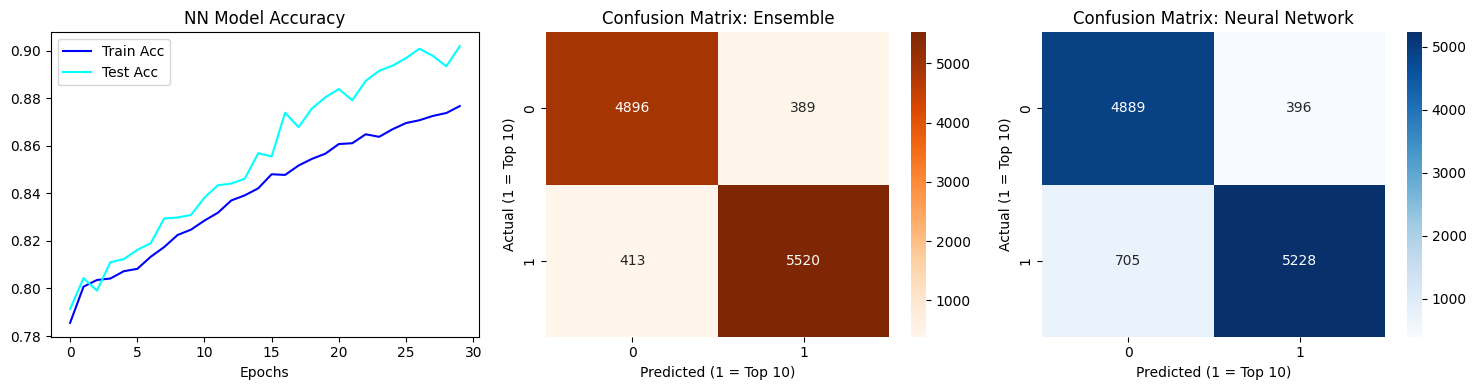

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import LambdaCallback

# ==========================================
# 1. โหลดข้อมูลและจัดการ Data Leakage
# ==========================================
print("โหลดข้อมูล f1_master_dataset.csv")
df = pd.read_csv('f1_master_dataset.csv')

# ตรวจสอบชื่อ Target
if 'Target' in df.columns:
    y = df['Target']
    X = df.drop(['Target'], axis=1)
elif 'FinishPosition' in df.columns:
    y = (df['FinishPosition'] <= 0.5).astype(int)
    X = df.drop(['FinishPosition'], axis=1)
else:
    raise ValueError("ไม่พบคอลัมน์ Target หรือ FinishPosition ใน Dataset")

# ลบข้อมูลที่รู้ผลหลังแข่งจบออกให้หมด
cols_to_drop = ['DNF', 'Overtakes', 'PitStopCount', 'TotalPitStops', 'AvgPitStopTime']
X = X.drop(columns=[c for c in cols_to_drop if c in X.columns], errors='ignore')

# แบ่งข้อมูล (Train 80%, Test 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"เตรียมข้อมูลเสร็จสิ้น ใช้ Feature ทั้งหมด {X.shape[1]} ตัว")
print("-" * 50)

# ==========================================
# 2. Train Model 1: Ensemble (ครบ 3 ประเภทตามโจทย์ PDF)
# ==========================================
print("กำลังเทรน Model 1: Ensemble Learning (RF + GB + LR)...")
start_ml = time.time()

# 2.1 สร้างโมเดล 3 ประเภทที่แตกต่างกัน
m1 = RandomForestClassifier(n_estimators=100, random_state=42)
m2 = GradientBoostingClassifier(n_estimators=100, random_state=42)
m3 = LogisticRegression(max_iter=1000, random_state=42)

# 2.2 รวมโมเดลด้วย Voting Classifier
ensemble_model = VotingClassifier(
    estimators=[('rf', m1), ('gb', m2), ('lr', m3)],
    voting='soft'
)
ensemble_model.fit(X_train, y_train)

# 2.3 เซฟโมเดล
joblib.dump(ensemble_model, 'f1_ensemble_model_v3.pkl')

ml_time = time.time() - start_ml
y_pred_ml = ensemble_model.predict(X_test)
acc_ml = accuracy_score(y_test, y_pred_ml) * 100

print(f"เทรน Ensemble เสร็จใน {ml_time:.2f} วินาที")
print(f"Ensemble Model Accuracy: {acc_ml:.2f}%")
print("-" * 50)

# ==========================================
# 3. Train Model 2: Neural Network
# ==========================================
print("กำลังสร้างและเทรน Model 2: Neural Network...")

# 3.1 ออกแบบโครงสร้าง
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3.2 ตั้งค่าการแสดงผล
total_epochs = 30
def on_epoch_end_custom(epoch, logs):
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f" >> รอบที่ {epoch+1:02d}/{total_epochs} | "
              f"ความแม่นยำ (Train): {logs['accuracy']*100:.2f}% | "
              f"(Test): {logs['val_accuracy']*100:.2f}%")

epoch_timer = LambdaCallback(on_epoch_end=on_epoch_end_custom)

start_nn = time.time()
history = nn_model.fit(
    X_train, y_train,
    epochs=total_epochs,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0,
    callbacks=[epoch_timer]
)

# 3.3 เซฟโมเดล
nn_model.save('f1_nn_model_v3.h5')

nn_time = time.time() - start_nn
test_loss, test_acc = nn_model.evaluate(X_test, y_test, verbose=0)
y_pred_nn = (nn_model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()

print(f"เทรน Neural Network เสร็จใน {nn_time:.2f} วินาที")
print(f"Neural Network Test Accuracy: {test_acc*100:.2f}%")
print("-" * 50)

# ==========================================
#  4. สรุปผลความแม่นยำและการประเมิน (Evaluation)
# ==========================================
print("\n--- ผลการทดสอบโมเดล (Classification Report) ---")

print("\n[1] Ensemble Model (RF + GB + LR)")
print(classification_report(y_test, y_pred_ml))

print("\n[2] Neural Network")
print(classification_report(y_test, y_pred_nn))

# ==========================================
#  5. สร้างกราฟแสดงผลลัพธ์
# ==========================================
plt.figure(figsize=(15, 4))

# 5.1 กราฟ Accuracy ของ Neural Network
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Train Acc', color='blue')
plt.plot(history.history['val_accuracy'], label='Test Acc', color='cyan')
plt.title('NN Model Accuracy')
plt.xlabel('Epochs')
plt.legend()

# 5.2 Confusion Matrix - Ensemble
plt.subplot(1, 3, 2)
sns.heatmap(confusion_matrix(y_test, y_pred_ml), annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix: Ensemble")
plt.xlabel("Predicted (1 = Top 10)")
plt.ylabel("Actual (1 = Top 10)")

# 5.3 Confusion Matrix - Neural Network
plt.subplot(1, 3, 3)
sns.heatmap(confusion_matrix(y_test, y_pred_nn), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Neural Network")
plt.xlabel("Predicted (1 = Top 10)")
plt.ylabel("Actual (1 = Top 10)")

plt.tight_layout()
plt.show()